# 03 · Geospatial Analysis — Restaurants de Niamey
**Entrée :** `data/processed/restaurants_clean.csv`  
**Objectif :** Géocoder les adresses Google Plus Code, analyser la distribution
spatiale des restaurants, identifier les zones de concentration et les zones
sous-servies.

### Plan
1. Géocodage des Plus Codes → lat/lng
2. Contrôle qualité des coordonnées
3. Carte interactive des restaurants (Folium)
4. Heatmap de densité & heatmap pondérée par score
5. Clustering spatial DBSCAN
6. Market gap géographique — zones sous-servies bien notées
7. Export HTML (prêt pour portfolio GitHub Pages)


## 0 · Imports & configuration

In [1]:
!pip install folium openlocationcode scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import folium
from folium.plugins import HeatMap, MarkerCluster, HeatMapWithTime, Fullscreen
import re
import warnings
from pathlib import Path
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import duckdb

try:
    from openlocationcode import openlocationcode as olc
    OLC_AVAILABLE = True
    print("✅ openlocationcode disponible")
except ImportError:
    OLC_AVAILABLE = False
    print("⚠️  openlocationcode non installé → pip install openlocationcode")

warnings.filterwarnings("ignore")

# ── Constantes ─────────────────────────────────────────────────────────────
NIAMEY_LAT  = 13.5137   # Centre de Niamey
NIAMEY_LNG  =  2.1098
NIAMEY_ZOOM = 13

PROC      = Path("../data/processed/restaurants_clean.csv")
GEO_OUT   = Path("../data/processed/restaurants_geo.csv")
MAP_DIR   = Path("../data/processed/maps")
MAP_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {
    "excellent": "#059669",  # ≥4.5
    "bon":       "#22C55E",  # 4.0–4.4
    "moyen":     "#F59E0B",  # 3.5–3.9
    "faible":    "#EF4444",  # <3.5
    "no_score":  "#94A3B8",
}

def score_color(score) -> str:
    if pd.isna(score): return PALETTE["no_score"]
    if score >= 4.5:   return PALETTE["excellent"]
    if score >= 4.0:   return PALETTE["bon"]
    if score >= 3.5:   return PALETTE["moyen"]
    return PALETTE["faible"]

print(f"Dossier cartes : {MAP_DIR.resolve()}")

✅ openlocationcode disponible
Dossier cartes : /home/user/Niamey_restaurants_analysis/data/processed/maps


## 1 · Chargement des données

In [2]:
df = pd.read_csv(PROC, encoding="utf-8-sig")
print(f"Shape : {df.shape}")
print(f"Champ street — NaN : {df['street'].isna().sum()} | Plus Codes : {df['is_plus_code'].sum()}")
df[["name","street","is_plus_code","score_bayes","category_clean"]].head(6)


Shape : (490, 21)
Champ street — NaN : 58 | Plus Codes : 331


,name,street,is_plus_code,score_bayes,category_clean
0,Amandine,G476+RX4,True,3.906,Restaurant
1,Bab Salam Maurice Delens,G3MW+WR4,True,3.906,Fast food
2,Rawda,"G4H4+8R9, Bd du Zarmaganda",True,3.813,Restaurant
3,Le Moulin Restaurant Boulangerie Pâtisserie Al...,"H325+Q44, RN1",True,4.007,Restaurant
4,RESTAURANT LE PILIER,rue de la tapoa,False,4.194,Restaurant
5,Côté Jardin,G492+XRX,True,4.287,Restaurant


## 2 · Géocodage des Plus Codes
Les adresses au format **Google Plus Code** (ex. `G476+RX4`) sont des codes
court (*short code*) qui nécessitent une position de référence pour être
décodés. On utilise le centre de Niamey comme référence.

**Stratégie :**
1. Extraire le Plus Code de la colonne `street`
2. Le récupérer en code complet via `recoverNearest()` + coordonnées Niamey
3. Décoder vers lat/lng centroïde de la cellule Plus Code
4. Pour les adresses textuelles non-Plus Code → assigner coordonnées Niamey
   centre comme fallback (à affiner avec géocodage externe si besoin)


In [3]:
PLUS_CODE_RE = re.compile(r'([A-Z0-9]{4,}\+[A-Z0-9]{2,})', re.IGNORECASE)

def decode_plus_code(street_val: str) -> tuple:
    """
    Extrait et décode un Plus Code depuis une chaîne d'adresse.
    Retourne (latitude, longitude) ou (None, None) si impossible.
    """
    if pd.isna(street_val) or not OLC_AVAILABLE:
        return None, None

    match = PLUS_CODE_RE.search(str(street_val).upper())
    if not match:
        return None, None

    raw_code = match.group(1)

    try:
        # Code complet (≥8 chars avant le '+')
        if olc.isValid(raw_code) and olc.isFull(raw_code):
            area = olc.decode(raw_code)
            return round(area.latitudeCenter, 6), round(area.longitudeCenter, 6)

        # Code court → récupération avec référence Niamey
        if olc.isShort(raw_code):
            full_code = olc.recoverNearest(raw_code, NIAMEY_LAT, NIAMEY_LNG)
            area      = olc.decode(full_code)
            return round(area.latitudeCenter, 6), round(area.longitudeCenter, 6)

    except Exception as e:
        print(f"Erreur de décodage Plus Code '{raw_code}' : {e}")
        return None, None

    return None, None


# Appliquer sur toutes les lignes
latitudes, longitudes = zip(*df["street"].apply(decode_plus_code))
df["lat"] = pd.Series(latitudes, dtype=float)
df["lng"] = pd.Series(longitudes, dtype=float)

print(f"DEBUG: df['lat'].dtype: {df['lat'].dtype}")
print(f"DEBUG: df['lat'].notna().sum() after assignment: {df['lat'].notna().sum()}")

print(f"Coordonnées obtenues   : {df['lat'].notna().sum()} / {len(df)}")
print(f"Sans coordonnées       : {df['lat'].isna().sum()}")
print()
print("Plages de coordonnées :")
print(f"  lat → [{df['lat'].min():.4f}, {df['lat'].max():.4f}]")
print(f"  lng → [{df['lng'].min():.4f}, {df['lng'].max():.4f}]")

DEBUG: df['lat'].dtype: float64
DEBUG: df['lat'].notna().sum() after assignment: 331
Coordonnées obtenues   : 331 / 490
Sans coordonnées       : 159

Plages de coordonnées :
  lat → [13.4637, 13.5954]
  lng → [1.9656, 2.1940]


## 3 · Contrôle qualité des coordonnées

**Validation géographique :** Niamey s'étend approximativement entre
- lat : 13.45° N — 13.60° N
- lng : 2.05° E — 2.20° E

Toute coordonnée hors de cette boîte englobante est suspecte.


In [4]:
LAT_MIN, LAT_MAX =  13.30,  13.80
LNG_MIN, LNG_MAX =   1.85,   2.35

df["coord_valid"] = (
    df["lat"].notna() & df["lng"].notna() &
    df["lat"].between(LAT_MIN, LAT_MAX) &
    df["lng"].between(LNG_MIN, LNG_MAX)
)

n_valid   = df["coord_valid"].sum()
n_invalid = df["lat"].notna().sum() - n_valid
n_missing = df["lat"].isna().sum()

print(f"Coordonnées valides        : {n_valid}")
print(f"Coordonnées hors bbox      : {n_invalid}")
print(f"Coordonnées manquantes     : {n_missing}")

# Mettre à NaN les coordonnées hors bbox
df.loc[~df["coord_valid"], ["lat","lng"]] = np.nan
print(f"\nDataset géo-exploitable   : {df['lat'].notna().sum()} restaurants")

Coordonnées valides        : 331
Coordonnées hors bbox      : 0
Coordonnées manquantes     : 159

Dataset géo-exploitable   : 331 restaurants


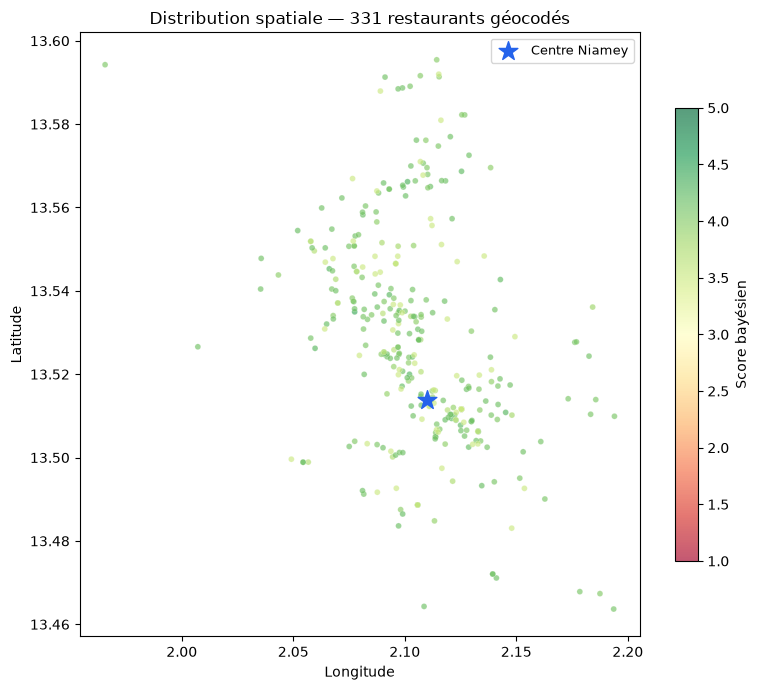

In [5]:
# Vérification visuelle — scatter rapide matplotlib
fig, ax = plt.subplots(figsize=(8, 7))

df_geo = df[df["lat"].notna()].copy()

sc = ax.scatter(
    df_geo["lng"], df_geo["lat"],
    c=df_geo["score_bayes"].fillna(3.5),
    cmap="RdYlGn", s=18, alpha=0.65, vmin=1, vmax=5,
    edgecolors="white", linewidths=0.2
)
ax.scatter(NIAMEY_LNG, NIAMEY_LAT, marker="*", s=200, color="#2563EB",
           zorder=5, label="Centre Niamey")
plt.colorbar(sc, ax=ax, label="Score bayésien", shrink=0.75)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Distribution spatiale — {len(df_geo)} restaurants géocodés")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(MAP_DIR / "spatial_scatter.png", dpi=130, bbox_inches="tight")
plt.show()

## 4 · Cartes Folium

### 4.1 Carte des marqueurs — score bayésien & catégorie


In [6]:
def build_popup(row: pd.Series) -> str:
    """Génère le HTML du popup Folium pour un restaurant."""
    score = row.get("score_bayes")
    stars_count = 0
    if pd.notna(score):
        stars_count = int(round(score))
    stars = "★" * stars_count

    score_disp = f"{score:.2f}" if pd.notna(score) else "N/A"
    reviews    = int(row.get("reviews_count", 0))
    website    = (f'<a href="{row["website"]}" target="_blank">🌐 Site web</a>'
                  if row.get("has_website") else "Pas de site web")
    phone      = row.get("phone") if row.get("has_phone") else "—"

    return f"""
    <div style="font-family:sans-serif;min-width:200px">
        <b style="font-size:14px">{row['name']}</b><br>
        <span style="color:#64748B;font-size:12px">{row.get('category_clean','')}</span><br>
        <hr style="margin:6px 0">
        <span style="font-size:16px;color:{'#059669' if pd.notna(score) and score>=4 else '#EF4444'}">{score_disp} ★</span>
        &nbsp;&nbsp;<span style="color:#94A3B8;font-size:11px">{reviews} avis</span><br>
        <span style="font-size:11px;color:#475569">Tier : {row.get('reliability_tier','—')}</span><br>
        <br>📞 {phone}<br>{website}
    </div>
    """

In [7]:
def score_to_radius(reviews_count: int) -> int:
    """Calcule le rayon du marqueur basé sur le nombre d'avis."""
    if reviews_count < 5:
        return 5
    elif reviews_count < 20:
        return 7
    elif reviews_count < 50:
        return 9
    else:
        return 12

# ── Carte 1 : Marqueurs colorés par score bayésien ────────────────────────
m_markers = folium.Map(
    location=[NIAMEY_LAT, NIAMEY_LNG],
    zoom_start=NIAMEY_ZOOM,
    tiles="CartoDB positron",
)
Fullscreen().add_to(m_markers)

# Groupe par catégorie pour le layer control
layer_groups = {}
for cat in df_geo["category_clean"].unique():
    fg = folium.FeatureGroup(name=cat, show=True)
    layer_groups[cat] = fg
    m_markers.add_child(fg)

for _, row in df_geo.iterrows():
    color   = score_color(row.get("score_bayes"))
    radius  = score_to_radius(int(row.get("reviews_count", 0)))
    popup   = folium.Popup(build_popup(row), max_width=280)
    tooltip = f"{row['name']} — {row.get('score_bayes', '?')} ★"

    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=radius,
        color=color, fill=True, fill_color=color, fill_opacity=0.75,
        weight=1.2,
        popup=popup,
        tooltip=tooltip,
    ).add_to(layer_groups.get(row["category_clean"], m_markers))

# Légende score
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
     background:white;padding:12px 16px;border-radius:10px;
     box-shadow:0 2px 8px rgba(0,0,0,.2);font-family:sans-serif;font-size:12px">
  <b>Score bayésien</b><br>
  <span style="color:#059669">●</span> ≥ 4.5 — Excellent<br>
  <span style="color:#22C55E">●</span> 4.0–4.4 — Bon<br>
  <span style="color:#F59E0B">●</span> 3.5–3.9 — Moyen<br>
  <span style="color:#EF4444">●</span> < 3.5 — Faible<br>
  <span style="color:#94A3B8">●</span> Non noté<br>
  <i style="color:#475569;font-size:10px">Taille = volume d'avis</i>
</div>
"""
m_markers.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m_markers)

path_markers = MAP_DIR / "map_01_markers.html"
m_markers.save(str(path_markers))
print(f"✅ Carte marqueurs sauvegardée : {path_markers}")

✅ Carte marqueurs sauvegardée : ../data/processed/maps/map_01_markers.html


### 4.2 Heatmap de densité

In [8]:
# ── Carte 2 : Heatmap de densité brute ───────────────────────────────────
m_heat = folium.Map(
    location=[NIAMEY_LAT, NIAMEY_LNG],
    zoom_start=NIAMEY_ZOOM,
    tiles="CartoDB dark_matter",
)
Fullscreen().add_to(m_heat)

heat_data = df_geo[["lat","lng"]].values.tolist()
HeatMap(
    heat_data,
    min_opacity=0.3,
    max_opacity=0.85,
    radius=20,
    blur=18,
    gradient={0.2: "#2563EB", 0.5: "#F59E0B", 0.8: "#EF4444", 1.0: "#7C2D12"},
).add_to(m_heat)

path_heat = MAP_DIR / "map_02_heatmap_density.html"
m_heat.save(str(path_heat))
print(f"✅ Heatmap densité : {path_heat}")


✅ Heatmap densité : ../data/processed/maps/map_02_heatmap_density.html


### 4.3 Heatmap pondérée par score bayésien

In [9]:
# ── Carte 3 : Heatmap pondérée par score bayésien ─────────────────────
# Interprétation : zones chaudes = forte concentration de bons restaurants
m_score = folium.Map(
    location=[NIAMEY_LAT, NIAMEY_LNG],
    zoom_start=NIAMEY_ZOOM,
    tiles="CartoDB positron",
)
Fullscreen().add_to(m_score)

df_scored = df_geo[df_geo["score_bayes"].notna() & (df_geo["reviews_count"] >= 5)].copy()
# Poids = score bayésien normalisé [0,1]
df_scored["weight"] = (df_scored["score_bayes"] - 1) / 4

heat_score = df_scored[["lat","lng","weight"]].values.tolist()
HeatMap(
    heat_score,
    min_opacity=0.25,
    max_opacity=0.80,
    radius=22,
    blur=20,
    gradient={0.0: "#94A3B8", 0.4: "#22C55E", 0.7: "#059669", 1.0: "#065F46"},
).add_to(m_score)

# Titre
title_html = """
<div style="position:fixed;top:15px;left:50%;transform:translateX(-50%);
     z-index:1000;background:white;padding:8px 18px;border-radius:8px;
     box-shadow:0 2px 6px rgba(0,0,0,.2);font-family:sans-serif;font-size:13px;font-weight:700">
  Zones de qualité — Score bayésien pondéré (vert intense = meilleur)
</div>
"""
m_score.get_root().html.add_child(folium.Element(title_html))

path_score = MAP_DIR / "map_03_heatmap_score.html"
m_score.save(str(path_score))
print(f"✅ Heatmap score : {path_score}")


✅ Heatmap score : ../data/processed/maps/map_03_heatmap_score.html


## 5 · Clustering spatial — DBSCAN
DBSCAN est idéal ici car :
- Pas besoin de spécifier le nombre de clusters à l'avance
- Gère les formes arbitraires (quartiers irréguliers)
- Identifie les points isolés (outliers géographiques)

**Paramètres :**
- `eps` = 0.008° ≈ 890 m (rayon de voisinage)
- `min_samples` = 4 (au moins 4 restaurants pour former un cluster)


In [10]:
df_clust = df_geo[df_geo["lat"].notna()].copy()
coords   = df_clust[["lat","lng"]].values

# ── Paramètres révisés ────────────────────────────────────────────────────
# eps=0.008° (890 m) créait un seul mega-cluster de 257 restaurants
# couvrant toute la ville → granularité inexploitable.
# eps=0.005° (≈556 m) = rayon quartier, cohérent avec les distances
# piétonnes entre zones de Niamey.
# min_samples=3 (vs 4) pour capturer les zones moins denses (Gamkalé, Goudel).
eps_deg     = 0.005   # ≈ 556 m
min_samples = 3

db = DBSCAN(eps=eps_deg, min_samples=min_samples, metric="euclidean").fit(coords)
df_clust["cluster"] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise    = (db.labels_ == -1).sum()

print(f"eps             : {eps_deg}° ≈ {int(eps_deg * 111_000)} m")
print(f"min_samples     : {min_samples}")
print(f"Clusters        : {n_clusters}")
print(f"Points isolés   : {n_noise} ({n_noise/len(df_clust)*100:.1f}%)")
print()

cluster_profiles = (
    df_clust[df_clust["cluster"] >= 0]
    .groupby("cluster")
    .agg(
        nb_restaurants = ("name",           "count"),
        score_moyen    = ("score_bayes",    "mean"),
        top_cat        = ("category_clean", lambda x: x.value_counts().index[0]),
        lat_center     = ("lat",            "mean"),
        lng_center     = ("lng",            "mean"),
        total_avis     = ("reviews_count",  "sum"),
    )
    .sort_values("nb_restaurants", ascending=False)
    .round(3)
)
print(cluster_profiles.to_string())


eps             : 0.005° ≈ 555 m
min_samples     : 3
Clusters        : 14
Points isolés   : 72 (21.8%)

         nb_restaurants  score_moyen     top_cat  lat_center  lng_center  total_avis
cluster                                                                             
0                    91        4.086  Restaurant      13.511       2.125        2382
1                    84        4.051  Restaurant      13.531       2.095        4461
2                    18        4.054  Restaurant      13.543       2.065         749
5                    13        4.128  Restaurant      13.567       2.106         112
9                    11        4.077  Restaurant      13.549       2.078          48
8                    10        4.089  Restaurant      13.562       2.087          64
7                     8        4.056  Restaurant      13.502       2.093          36
4                     5        3.917  Restaurant      13.548       2.096         114
13                    4        4.128  Restaura

## 5ter · Fusion en méta-zones (anti-fragmentation)
Avec `eps=556m`, DBSCAN scinde parfois une même zone piétonne en plusieurs
sous-clusters distincts (ex. *Koira Tégui Nord* apparaissait 3 fois dans la
légende avec des IDs différents). Ce n'est pas un bug de nommage — ce sont
**bien des clusters DBSCAN différents** dont les centroïdes tombent par
coïncidence près du même quartier de référence.

**Solution :** un clustering hiérarchique (linkage complet) sur les
centroïdes des clusters DBSCAN, qui fusionne ceux distants de moins de
`MERGE_DIST_M` en une seule méta-zone. Le clustering fin au niveau
restaurant (`cluster`) est conservé pour référence ; un nouveau niveau
agrégé (`meta_cluster`) est utilisé pour l'affichage (légende, marqueurs).


In [11]:
from scipy.cluster.hierarchy import linkage, fcluster

MERGE_DIST_M = 750  # distance max (m) sous laquelle deux clusters DBSCAN
                    # voisins sont considérés comme la même zone piétonne

def merge_nearby_clusters(df_points: pd.DataFrame, merge_dist_m: float) -> pd.Series:
    """
    Fusionne les clusters DBSCAN proches en méta-zones cohérentes, via
    clustering hiérarchique (linkage complet) sur la distance inter-
    centroïdes en mètres.

    Args:
        df_points    : DataFrame niveau restaurant, colonnes 'cluster','lat','lng'
        merge_dist_m : seuil de fusion en mètres

    Returns:
        pd.Series alignée sur df_points : id de méta-zone (-1 = bruit, inchangé)
    """
    sub = df_points[df_points["cluster"] >= 0]
    centroids = sub.groupby("cluster")[["lat", "lng"]].mean()

    if len(centroids) <= 1:
        mapping = {cid: 0 for cid in centroids.index}
    else:
        m_per_deg_lat = 111_000
        m_per_deg_lng = 111_000 * np.cos(np.radians(NIAMEY_LAT))
        coords_m = np.column_stack([
            centroids["lat"].values * m_per_deg_lat,
            centroids["lng"].values * m_per_deg_lng,
        ])
        Z      = linkage(coords_m, method="complete")
        labels = fcluster(Z, t=merge_dist_m, criterion="distance")
        mapping = dict(zip(centroids.index, labels - 1))  # 0-indexé

    meta = df_points["cluster"].map(mapping)
    meta = meta.where(df_points["cluster"] >= 0, -1).astype(int)
    return meta


df_clust["meta_cluster"] = merge_nearby_clusters(df_clust, merge_dist_m=MERGE_DIST_M)

n_before = df_clust.loc[df_clust["cluster"] >= 0, "cluster"].nunique()
n_after  = df_clust.loc[df_clust["meta_cluster"] >= 0, "meta_cluster"].nunique()

print(f"Clusters DBSCAN bruts          : {n_before}")
print(f"Méta-zones après fusion ≤{MERGE_DIST_M}m : {n_after}")
print(f"Réduction                       : -{n_before - n_after} clusters fragmentés fusionnés")

# ── Reconstruction de cluster_profiles sur les méta-zones ──────────────────
# (recalculé depuis les restaurants individuels, pas par moyenne pondérée
#  des anciens centroïdes — plus correct statistiquement)
cluster_profiles = (
    df_clust[df_clust["meta_cluster"] >= 0]
    .groupby("meta_cluster")
    .agg(
        nb_restaurants = ("name",           "count"),
        score_moyen    = ("score_bayes",    "mean"),
        top_cat        = ("category_clean", lambda x: x.value_counts().index[0]),
        lat_center     = ("lat",            "mean"),
        lng_center     = ("lng",            "mean"),
        total_avis     = ("reviews_count",  "sum"),
    )
    .sort_values("nb_restaurants", ascending=False)
    .round(3)
)
cluster_profiles.index.name = "cluster"   # compatibilité avec le reste du notebook

print()
print(cluster_profiles.to_string())


Clusters DBSCAN bruts          : 14
Méta-zones après fusion ≤750m : 14
Réduction                       : -0 clusters fragmentés fusionnés

         nb_restaurants  score_moyen     top_cat  lat_center  lng_center  total_avis
cluster                                                                             
11                   91        4.086  Restaurant      13.511       2.125        2382
7                    84        4.051  Restaurant      13.531       2.095        4461
5                    18        4.054  Restaurant      13.543       2.065         749
4                    13        4.128  Restaurant      13.567       2.106         112
6                    11        4.077  Restaurant      13.549       2.078          48
3                    10        4.089  Restaurant      13.562       2.087          64
10                    8        4.056  Restaurant      13.502       2.093          36
2                     5        3.917  Restaurant      13.548       2.096         114
9          

In [12]:
# ── Référentiel officiel des quartiers de Niamey ────────────────────────────
# Source : découpage administratif Niamey (5 arrondissements, 101 quartiers)
# Remplace les bounding boxes manuelles par une recherche au plus proche voisin.

import io
from scipy.spatial import KDTree

QUARTIERS_CSV = """Arrondissement;Quartier;Latitude;Longitude
Niamey I;Bobiel;13.5508;2.1153
Niamey I;Château 1;13.5350;2.0862
Niamey I;Cité Chinoise;13.5414;2.1111
Niamey I;Corniche Yantala;13.5112;2.0815
Niamey I;Francophonie;13.5452;2.1025
Niamey I;Garde Présidentielle;13.5220;2.0910
Niamey I;Gendarmerie;13.5195;2.0945
Niamey I;Goudel;13.5306;2.0722
Niamey I;Goudel Gorou;13.5385;2.0650
Niamey I;Issa Béri;13.5320;2.1010
Niamey I;Koira Tégui Centre;13.5615;2.1085
Niamey I;Koira Tégui Nord;13.5702;2.1040
Niamey I;Koira Tégui Sud;13.5550;2.1110
Niamey I;Koubia;13.5492;2.0645
Niamey I;Lossougoungou;13.5390;2.0790
Niamey I;Maourey;13.5180;2.1030
Niamey I;Riyad;13.5435;2.1215
Niamey I;Soni;13.5210;2.0990
Niamey I;Tchangarey;13.5585;2.1280
Niamey I;Yantala Bas;13.5140;2.0880
Niamey I;Yantala Haut;13.5245;2.0912
Niamey I;Zongo;13.5165;2.1070
Niamey II;Banifandou I;13.5410;2.1285
Niamey II;Banifandou II;13.5430;2.1315
Niamey II;Banizoumbou I;13.5280;2.1250
Niamey II;Banizoumbou II;13.5320;2.1290
Niamey II;Boukoki I;13.5333;2.1167
Niamey II;Boukoki II;13.5352;2.1210
Niamey II;Boukoki III;13.5370;2.1235
Niamey II;Boukoki IV;13.5395;2.1260
Niamey II;Cité Caisse;13.5315;2.1090
Niamey II;Cité Député;13.5460;2.1190
Niamey II;Cité Fayçal;13.5345;2.1040
Niamey II;Dan Zama Koira;13.5510;2.1240
Niamey II;Dar Es Salam;13.5375;2.1080
Niamey II;Faisceau Nord;13.5530;2.1055
Niamey II;Gandatché;13.5255;2.1150
Niamey II;Hamdallaye;13.5240;2.1210
Niamey II;Lazaret;13.5440;2.1390
Niamey II;Liberté;13.5295;2.1140
Niamey II;Maanat;13.5380;2.1460
Niamey II;Madina;13.5265;2.1325
Niamey II;Nord Lazaret;13.5520;2.1420
Niamey II;Sonuci;13.5535;2.1350
Niamey II;Tourakou;13.5480;2.1490
Niamey II;Zone Industrielle;13.5322;2.1428
Niamey III;Anikwara;13.5130;2.1120
Niamey III;Bagdad;13.5185;2.1480
Niamey III;Dangawo;13.5110;2.1210
Niamey III;Danyassamé;13.5200;2.1200
Niamey III;Deyzeibon;13.5145;2.1175
Niamey III;Gaweye I (Rive gauche);13.5090;2.1070
Niamey III;Kalley Est;13.5160;2.1340
Niamey III;Kalley Sud;13.5120;2.1310
Niamey III;Kombo;13.5180;2.1390
Niamey III;Kwarakano;13.5175;2.1245
Niamey III;Lakouroussou;13.5190;2.1270
Niamey III;Plateau I;13.5178;2.1044
Niamey III;Plateau II;13.5215;2.1075
Niamey III;Sabon Gari;13.5225;2.1360
Niamey III;Terminus;13.5105;2.1145
Niamey III;Wadata;13.5208;2.1328
Niamey III;Zabarkane;13.5150;2.1435
Niamey IV;Aéroport;13.4894;2.1736
Niamey IV;Aviation;13.4980;2.1640
Niamey IV;Bassi;13.4720;2.1690
Niamey IV;Cité Aéroport;13.4920;2.1810
Niamey IV;Cité ASCOMA;13.5050;2.1520
Niamey IV;Cité CNSS;13.5095;2.1445
Niamey IV;Gami;13.4430;2.1820
Niamey IV;Gamkallé Golé;13.4990;2.1320
Niamey IV;Gamkallé Sébastien;13.4975;2.1275
Niamey IV;Néni Goungou;13.4810;2.1335
Niamey IV;Nouveau Marché;13.5135;2.1395
Niamey IV;Pays-Bas;13.5080;2.1660
Niamey IV;Saga Fondé;13.4780;2.1450
Niamey IV;Saga Gorou;13.4830;2.1590
Niamey IV;Saga Sambou;13.4735;2.1510
Niamey IV;Sari;13.5110;2.1580
Niamey IV;Soudouré;13.5015;2.1895
Niamey IV;Talladjé Centre;13.5014;2.1614
Niamey IV;Talladjé Est;13.5020;2.1685
Niamey IV;Talladjé Nord;13.5065;2.1605
Niamey IV;Talladjé Ouest;13.4995;2.1540
Niamey IV;Tollékou;13.4910;2.1420
Niamey V;AGRHYMET;13.4965;2.0910
Niamey V;Banga Bana;13.4985;2.0830
Niamey V;Banguisto;13.5050;2.0790
Niamey V;Cité Universitaire;13.4990;2.0965
Niamey V;Gawèye I;13.5083;2.1014
Niamey V;Gawèye II;13.5060;2.0970
Niamey V;Hôpital Gawèye;13.5030;2.1030
Niamey V;Hôpital Lamordé;13.4970;2.0990
Niamey V;INJS / Complexe;13.4935;2.1040
Niamey V;Karadjé;13.5025;2.0865
Niamey V;Kirkissoye Centre;13.4828;2.0839
Niamey V;Kirkissoye Extension;13.4750;2.0810
Niamey V;Lamordé;13.5005;2.0944
Niamey V;Lamordé Doundoun;13.5040;2.0915
Niamey V;Nialga;13.4795;2.0870
Niamey V;Pont Kennedy (Abords);13.5075;2.1045
Niamey V;Zarmagadey;13.5110;2.0745"""

ref_q = pd.read_csv(io.StringIO(QUARTIERS_CSV), sep=";")

# KDTree sur coordonnées brutes (degrés)
# Distorsion cos(13.5°) ≈ 0.972 → erreur < 3 % négligeable pour Niamey
_ref_coords = ref_q[["Latitude", "Longitude"]].values
_ktree      = KDTree(_ref_coords)

print(f"Référentiel chargé : {len(ref_q)} quartiers · {ref_q['Arrondissement'].nunique()} arrondissements")
print()
print(ref_q.groupby("Arrondissement").size().rename("nb_quartiers").to_string())


Référentiel chargé : 102 quartiers · 5 arrondissements

Arrondissement
Niamey I      22
Niamey II     24
Niamey III    17
Niamey IV     22
Niamey V      17


In [13]:
def approx_zone(lat: float, lng: float, level: str = "quartier") -> str:
    """
    Assigne le quartier officiel de Niamey le plus proche via KDTree.

    Args:
        lat, lng : coordonnées WGS-84
        level    : "quartier"       → "Niamey III · Plateau I"
                   "arrondissement" → "Niamey III"
                   "court"          → "Plateau I"   (pour labels de carte)
                   "label_carte"    → "Plateau I ⚠️" si dist > 1 500 m

    Le flag ⚠️ signale les centroïdes tombant hors du référentiel dense
    (zones périphériques ou erreurs de géocodage).
    """
    dist_deg, idx = _ktree.query([lat, lng])
    dist_m        = dist_deg * 111_000
    row           = ref_q.iloc[idx]
    arrdt         = row["Arrondissement"]
    quartier      = row["Quartier"]
    flag          = " ⚠️" if dist_m > 1_500 else ""

    if level == "arrondissement":  return arrdt
    if level == "court":           return quartier
    if level == "label_carte":     return f"{quartier}{flag}"
    return f"{arrdt} · {quartier}{flag}"


def zone_dist_m(lat: float, lng: float) -> int:
    """Distance en mètres au quartier de référence le plus proche."""
    dist_deg, _ = _ktree.query([lat, lng])
    return int(dist_deg * 111_000)


def _direction_suffix(d_lat: float, d_lng: float) -> str:
    """Suffixe cardinal (N/S/E/O + combinaisons) selon l'écart au quartier de réf."""
    ns = "N" if d_lat > 0.0015 else "S" if d_lat < -0.0015 else ""
    eo = "E" if d_lng > 0.0015 else "O" if d_lng < -0.0015 else ""
    s = ns + eo
    return f" ({s})" if s else ""


def dedupe_zone_names(profiles: pd.DataFrame) -> pd.DataFrame:
    """
    Désambiguïse les méta-zones partageant le même quartier de référence.

    Plusieurs clusters DBSCAN distincts peuvent retomber sur le même quartier
    officiel (ex. 'Koira Tégui Nord' isolé dans le référentiel). On suffixe
    alors chaque doublon par un repère directionnel calculé depuis le
    barycentre du quartier de référence — le nom reste lisible et unique.
    """
    p = profiles.copy()
    for base, grp in p.groupby("zone"):
        if len(grp) == 1:
            continue
        # barycentre du groupe homonyme
        clat, clng = grp["lat_center"].mean(), grp["lng_center"].mean()
        for idx in grp.index:
            suf = _direction_suffix(p.at[idx, "lat_center"] - clat,
                                    p.at[idx, "lng_center"] - clng)
            # fallback si deux centroïdes quasi confondus : numérotation
            p.at[idx, "zone"] = p.at[idx, "zone"] + suf
        # garantir l'unicité même après suffixe directionnel
        seen = {}
        for idx in grp.index:
            z = p.at[idx, "zone"]
            if z in seen:
                seen[z] += 1
                p.at[idx, "zone"] = f"{z} #{seen[z]}"
            else:
                seen[z] = 1
    return p


# ── Enrichissement des profils de clusters ──────────────────────────────────
cluster_profiles["zone"]           = cluster_profiles.apply(
    lambda r: approx_zone(r["lat_center"], r["lng_center"], level="quartier"), axis=1
)
cluster_profiles["arrondissement"] = cluster_profiles.apply(
    lambda r: approx_zone(r["lat_center"], r["lng_center"], level="arrondissement"), axis=1
)
cluster_profiles["zone_dist_m"]    = cluster_profiles.apply(
    lambda r: zone_dist_m(r["lat_center"], r["lng_center"]), axis=1
)

# Désambiguïsation des homonymes (méta-zones sur le même quartier de réf.)
cluster_profiles = dedupe_zone_names(cluster_profiles)

n_dupes_avant = cluster_profiles["zone"].str.replace(r" \([NSEO]+\).*| #\d+", "", regex=True).duplicated().sum()
print("Zones assignées (référentiel officiel Niamey) :")
print()
print(cluster_profiles[[
    "zone", "arrondissement", "zone_dist_m",
    "nb_restaurants", "score_moyen", "total_avis"
]].to_string())
print()
print(f"✅ Zones uniques : {cluster_profiles['zone'].nunique()} / {len(cluster_profiles)} méta-zones")
print("⚠️  Distance > 1 500 m = centroïde hors référentiel dense (périphérie).")

# ── Export pour 04_market_gaps.ipynb ────────────────────────────────────────
cluster_profiles.to_csv(Path("../data/processed/cluster_profiles.csv"), index=True)
print("\n✅ cluster_profiles.csv exporté")


Zones assignées (référentiel officiel Niamey) :

                                        zone arrondissement  zone_dist_m  nb_restaurants  score_moyen  total_avis
cluster                                                                                                          
11                      Niamey III · Dangawo     Niamey III          444              91        4.086        2382
7                       Niamey I · Issa Béri       Niamey I          675              84        4.051        4461
5                    Niamey I · Goudel Gorou       Niamey I          499              18        4.054         749
4                Niamey I · Koira Tégui Nord       Niamey I          418              13        4.128         112
6                   Niamey I · Lossougoungou       Niamey I         1115              11        4.077          48
3        Niamey I · Koira Tégui Nord ⚠️ (SO)       Niamey I         2095              10        4.089          64
10                        Niamey V · La

## 5bis · Légende des zones (remplace les labels flottants)
Les labels textuels superposés sur les centroïdes posaient deux problèmes :
chevauchement entre zones proches, et un rendu **vertical illisible** dès
que `word-wrap: break-word` cassait un nom de quartier sans espace (ex.
*Lossougoungou*, *Tchangarey*) dans un badge trop étroit.

**Solution adoptée :** des marqueurs simples (cercles colorés, sans texte)
sur la carte + une légende fixe listant toutes les zones, triée par taille.
Zéro collision possible, lisible à tout niveau de zoom.


In [14]:
def build_zone_legend_html(profiles: pd.DataFrame, max_height_px: int = 280,
                            legend_id: str = "zoneLegend") -> str:
    """
    Construit le panneau de légende listant les zones (clusters), trié par
    nombre de restaurants décroissant. Positionné en bas à droite pour ne
    JAMAIS chevaucher le LayerControl (en haut à droite) ni la légende
    score (en bas à gauche). Repliable via un bouton ▾/▸ pour ne pas
    encombrer l'écran, notamment sur mobile.
    """
    rows_html = ""
    for idx, cp in profiles.sort_values("nb_restaurants", ascending=False).iterrows():
        cid         = int(idx)
        color       = CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
        quality_clr = score_color(cp["score_moyen"])
        zone_label  = approx_zone(cp["lat_center"], cp["lng_center"], level="court")

        rows_html += f"""
            <div style="display:flex;align-items:center;gap:7px;padding:4px 0;
                 border-bottom:1px solid #F1F5F9;">
                <span style="width:11px;height:11px;border-radius:50%;flex-shrink:0;
                     background:{color};
                     box-shadow:inset 0 0 0 2px {quality_clr};"></span>
                <span style="flex:1;font-size:11px;color:#1E293B;
                     overflow:hidden;text-overflow:ellipsis;white-space:nowrap;">
                    {zone_label}
                </span>
                <span style="font-size:10px;color:#64748B;white-space:nowrap;">
                    {int(cp['nb_restaurants'])} · {cp['score_moyen']:.1f}★
                </span>
            </div>"""

    return f"""
    <div id="{legend_id}" style="position:fixed;bottom:25px;right:12px;z-index:998;
         background:rgba(255,255,255,.97);border-radius:10px;
         box-shadow:0 2px 10px rgba(0,0,0,.2);font-family:sans-serif;
         width:225px;">
        <div onclick="
                var body = document.getElementById('{legend_id}-body');
                var arrow = document.getElementById('{legend_id}-arrow');
                var open = body.style.display !== 'none';
                body.style.display = open ? 'none' : 'block';
                arrow.innerHTML = open ? '▸' : '▾';
             "
             style="padding:10px 14px;cursor:pointer;display:flex;
                    align-items:center;justify-content:space-between;">
            <b style="font-size:12px;color:#0F172A;">📍 Zones ({len(profiles)})</b>
            <span id="{legend_id}-arrow" style="color:#94A3B8;font-size:11px;">▾</span>
        </div>
        <div id="{legend_id}-body" style="display:block;padding:0 14px 12px;
             max-height:{max_height_px}px;overflow-y:auto;">
            <div style="font-size:9px;color:#94A3B8;margin:0 0 6px;line-height:1.4;">
                Anneau intérieur = qualité moyenne · triées par taille
            </div>
            {rows_html}
        </div>
    </div>
    """


def add_zone_markers(target, profiles: pd.DataFrame) -> None:
    """
    Ajoute un marqueur circulaire simple (sans texte) par zone — taille
    proportionnelle au nombre de restaurants, couleur = identité de la
    méta-zone, contour blanc épais pour le détacher du fond de carte.
    Le détail complet (nom, score, nb restos) apparaît au survol (tooltip).
    """
    n_min = profiles["nb_restaurants"].min()
    n_max = profiles["nb_restaurants"].max()
    span  = max(1, n_max - n_min)

    for idx, cp in profiles.iterrows():
        cid       = int(idx)
        color     = CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
        zone_full = approx_zone(cp["lat_center"], cp["lng_center"], level="quartier")
        radius    = 7 + 11 * (cp["nb_restaurants"] - n_min) / span

        folium.CircleMarker(
            location=[cp["lat_center"], cp["lng_center"]],
            radius=radius,
            color="white", weight=2.5,
            fill=True, fill_color=color, fill_opacity=0.92,
            tooltip=(f"{zone_full} — {int(cp['nb_restaurants'])} restaurants · "
                     f"{cp['score_moyen']:.2f}★"),
        ).add_to(target)


print("✅ Légende repositionnée (bottom-right, repliable) — plus de chevauchement avec LayerControl")


✅ Légende repositionnée (bottom-right, repliable) — plus de chevauchement avec LayerControl


In [15]:
# ── Carte 4 : Clusters DBSCAN ─────────────────────────────────────────────
CLUSTER_COLORS = [
    "#3B82F6","#8B5CF6","#F59E0B","#10B981","#EC4899",
    "#F97316","#14B8A6","#EF4444","#6366F1","#84CC16",
]

m_clust = folium.Map(
    location=[NIAMEY_LAT, NIAMEY_LNG],
    zoom_start=NIAMEY_ZOOM,
    tiles="CartoDB positron",
)
Fullscreen().add_to(m_clust)

# ── Points individuels (restaurants) ────────────────────────────────────────
for _, row in df_clust.iterrows():
    cid = row["meta_cluster"]   # couleur alignée sur la méta-zone (légende)
    if cid == -1:
        color, radius, opacity = "#94A3B8", 4, 0.4
    else:
        color   = CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
        radius  = score_to_radius(int(row.get("reviews_count", 0)))
        opacity = 0.78

    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=radius,
        color=color, fill=True, fill_color=color, fill_opacity=opacity,
        weight=1,
        tooltip=f"{'🔘 Isolé' if cid==-1 else f'Zone {cid}'} | {row['name']} ({row.get('score_bayes','?')} ★)",
        popup=folium.Popup(build_popup(row), max_width=260),
    ).add_to(m_clust)

# ── Marqueurs de centroïde (sans texte) + légende fixe ──────────────────────
add_zone_markers(m_clust, cluster_profiles)
m_clust.get_root().html.add_child(folium.Element(build_zone_legend_html(cluster_profiles)))

path_clust = MAP_DIR / "map_04_clusters.html"
m_clust.save(str(path_clust))
print(f"✅ Carte clusters : {path_clust}")
print(f"   {len(cluster_profiles)} zones listées dans la légende")


✅ Carte clusters : ../data/processed/maps/map_04_clusters.html
   14 zones listées dans la légende


## 6 · Market Gap géographique
Pour chaque cluster, on calcule un **indice d'opportunité** :
- Score bayésien moyen élevé = demande qualitative existante
- Nombre de restaurants faible = faible concurrence
- Score faible dans une zone dense = opportunité de challenger


In [16]:
con = duckdb.connect()
con.register("geo", df_clust[df_clust["cluster"] >= 0])
con.register("profiles", cluster_profiles.reset_index())

gap = con.execute("""
    SELECT
        g.cluster,
        p.zone,
        COUNT(*)                                          AS nb_restaurants,
        ROUND(AVG(g.score_bayes),  3)                    AS score_moyen,
        ROUND(MEDIAN(g.reviews_count), 0)                AS median_avis,
        ROUND(SUM(g.has_website::int)*100.0/COUNT(*),1) AS pct_web,
        ROUND(
            AVG(g.score_bayes) /
            NULLIF(COUNT(*), 0) * 10, 3
        )                                                AS opportunite_index
    FROM geo g
    JOIN profiles p ON g.cluster = p.cluster
    GROUP BY g.cluster, p.zone
    ORDER BY opportunite_index DESC
""").df()

print("═"*65)
print("  MARKET GAP PAR ZONE GÉOGRAPHIQUE")
print("═"*65)
print(gap.to_string(index=False))
print()
print("→ opportunite_index élevé = bon score dans une zone peu dense")


═════════════════════════════════════════════════════════════════
  MARKET GAP PAR ZONE GÉOGRAPHIQUE
═════════════════════════════════════════════════════════════════
 cluster                                zone  nb_restaurants  score_moyen  median_avis  pct_web  opportunite_index
      12              Niamey IV · Saga Fondé               3        4.135          1.0      0.0             13.783
      11                Niamey III · Dangawo               3        4.113          1.0      0.0             13.709
       6            Niamey I · Lossougoungou               3        4.104          4.0      0.0             13.681
      10                  Niamey V · Lamordé               3        3.975          2.0      0.0             13.248
       3 Niamey I · Koira Tégui Nord ⚠️ (SO)               3        3.961        187.0      0.0             13.204
      13            Niamey V · Zarmagadey ⚠️               4        4.128          1.0      0.0             10.320
       4         Niamey I · 

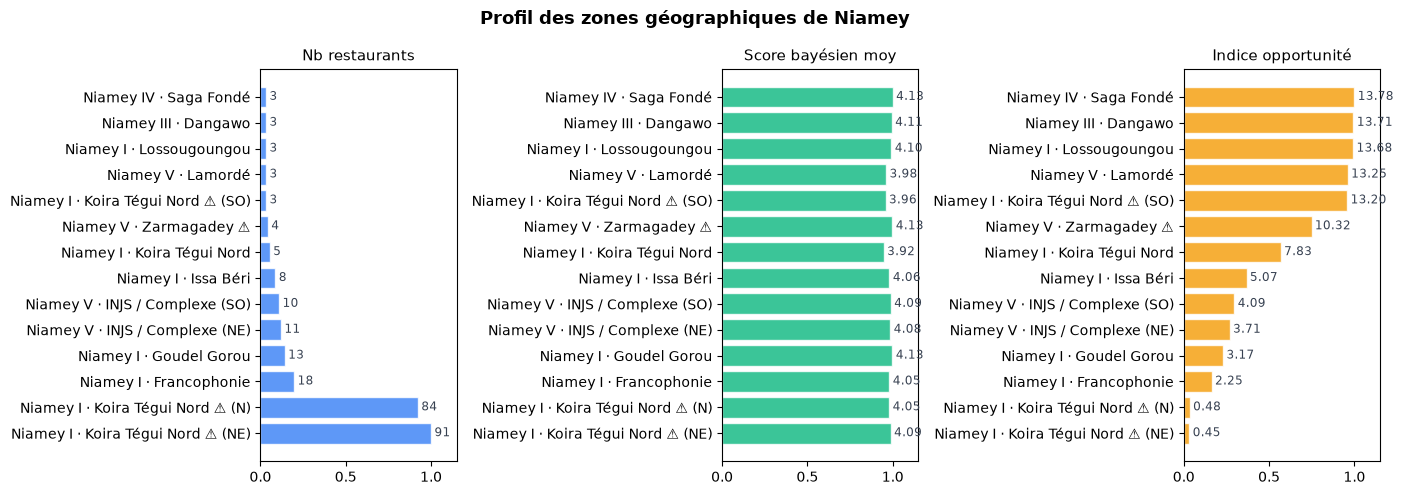

In [17]:
# Visualisation radar-like : barplot comparatif par zone
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Profil des zones géographiques de Niamey", fontsize=13, fontweight="bold")

metrics = [
    ("nb_restaurants", "Nb restaurants",    "#3B82F6"),
    ("score_moyen",    "Score bayésien moy","#10B981"),
    ("opportunite_index","Indice opportunité","#F59E0B"),
]

for ax, (col, label, color) in zip(axes, metrics):
    vals = gap[col]
    norm = vals / vals.max() if vals.max() > 0 else vals
    bars = ax.barh(gap["zone"], norm, color=color, alpha=0.82, edgecolor="white")
    ax.set_title(label, fontsize=11)
    ax.set_xlim(0, 1.15)
    ax.invert_yaxis()
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f"{v:.2f}" if isinstance(v, float) else str(int(v)),
                va="center", fontsize=8.5, color="#374151")

plt.tight_layout()
plt.savefig(MAP_DIR / "zone_profiles.png", dpi=140, bbox_inches="tight")
plt.show()


## 7 · Carte combinée — Portfolio
Carte finale tout-en-un avec onglets de layers : marqueurs + heatmap + clusters.
C'est **cette carte** qu'on embarque dans le README GitHub.


In [18]:
m_final = folium.Map(
    location=[NIAMEY_LAT, NIAMEY_LNG],
    zoom_start=NIAMEY_ZOOM,
    tiles=None,
)
Fullscreen().add_to(m_final)

# ── Fonds de carte ──────────────────────────────────────────────────────────
folium.TileLayer("CartoDB positron",    name="Clair",      show=True).add_to(m_final)
folium.TileLayer("CartoDB dark_matter", name="Sombre",     show=False).add_to(m_final)
folium.TileLayer("OpenStreetMap",       name="OpenStreetMap", show=False).add_to(m_final)

# ── Layer 1 : Marqueurs score ────────────────────────────────────────────────
fg_markers = folium.FeatureGroup(name="🗺️ Restaurants (score)", show=True)
mc = MarkerCluster(options={"disableClusteringAtZoom": 15})
for _, row in df_geo.iterrows():
    color  = score_color(row.get("score_bayes"))
    radius = score_to_radius(int(row.get("reviews_count", 0)))
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=radius,
        color=color, fill=True, fill_color=color, fill_opacity=0.78, weight=1.2,
        popup=folium.Popup(build_popup(row), max_width=270),
        tooltip=f"{row['name']} — {row.get('score_bayes','?')} ★",
    ).add_to(mc)
mc.add_to(fg_markers)
fg_markers.add_to(m_final)

# ── Layer 2 : Heatmap densité ─────────────────────────────────────────────
fg_heat = folium.FeatureGroup(name="🌡️ Heatmap densité", show=False)
HeatMap(
    df_geo[["lat","lng"]].values.tolist(),
    radius=20, blur=18, min_opacity=0.3,
    gradient={0.2:"#2563EB", 0.5:"#F59E0B", 1.0:"#EF4444"},
).add_to(fg_heat)
fg_heat.add_to(m_final)

# ── Layer 3 : Heatmap score ───────────────────────────────────────────────
fg_qscore = folium.FeatureGroup(name="⭐ Heatmap qualité", show=False)
df_s = df_geo[df_geo["score_bayes"].notna() & (df_geo["reviews_count"] >= 5)].copy()
df_s["w"] = (df_s["score_bayes"] - 1) / 4
HeatMap(
    df_s[["lat","lng","w"]].values.tolist(),
    radius=22, blur=20, min_opacity=0.25,
    gradient={0.0:"#94A3B8", 0.4:"#22C55E", 1.0:"#065F46"},
).add_to(fg_qscore)
fg_qscore.add_to(m_final)

# ── Layer 4 : Clusters DBSCAN — marqueurs simples (sans texte) ────────────
fg_cl = folium.FeatureGroup(name="🔵 Clusters DBSCAN", show=False)
for _, row in df_clust.iterrows():
    cid   = row["meta_cluster"]   # couleur alignée sur la méta-zone (légende)
    color = "#94A3B8" if cid == -1 else CLUSTER_COLORS[cid % len(CLUSTER_COLORS)]
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=6, color=color, fill=True, fill_color=color,
        fill_opacity=0.75, weight=1,
        tooltip=f"Zone {cid} | {row['name']}",
    ).add_to(fg_cl)

add_zone_markers(fg_cl, cluster_profiles)
fg_cl.add_to(m_final)

# ── Légendes ─────────────────────────────────────────────────────────────────
legend_score = """
<div style="position:fixed;bottom:25px;left:25px;z-index:1000;
     background:rgba(255,255,255,.95);padding:12px 16px;border-radius:10px;
     box-shadow:0 2px 10px rgba(0,0,0,.2);font-family:sans-serif;font-size:11px">
  <b style="font-size:12px">Score bayésien</b><br>
  <span style="color:#059669">●</span> ≥ 4.5 Excellent<br>
  <span style="color:#22C55E">●</span> 4.0–4.4 Bon<br>
  <span style="color:#F59E0B">●</span> 3.5–3.9 Moyen<br>
  <span style="color:#EF4444">●</span> &lt; 3.5 Faible<br>
  <span style="color:#94A3B8">●</span> Non noté<br>
  <hr style="margin:5px 0">
  <i style="color:#475569;font-size:10px">
    Taille marqueur = volume d'avis<br>
    Cliquer pour détails
  </i>
</div>
"""
m_final.get_root().html.add_child(folium.Element(legend_score))
m_final.get_root().html.add_child(folium.Element(build_zone_legend_html(cluster_profiles)))
folium.LayerControl(collapsed=False, position="topright").add_to(m_final)

path_final = MAP_DIR / "map_PORTFOLIO.html"
m_final.save(str(path_final))
print(f"✅  Carte portfolio : {path_final}")
print(f"    Taille          : {path_final.stat().st_size / 1024:.0f} Ko")
print(f"    Zones en légende : {len(cluster_profiles)}")


✅  Carte portfolio : ../data/processed/maps/map_PORTFOLIO.html
    Taille          : 854 Ko
    Zones en légende : 14


## 8 · Export du dataset enrichi

In [19]:
# ── Fusion du clustering dans le dataset principal ──────────────────────────
# BUG CORRIGÉ : meta_cluster n'existait que sur df_clust (sous-ensemble
# géocodé), jamais réintégré dans df → restaurants_geo.csv ne contenait
# JAMAIS de colonne 'cluster', rendant l'analyse catégorie × zone de
# 04_market_gaps.ipynb silencieusement inopérante (if "cluster" in df.columns
# était toujours False).
#
# Index préservé tout du long (df → df_geo → df_clust, simples filtres
# booléens sans reset_index) → merge par index sûr.
#
# Convention :
#   -2 = restaurant non géocodé (absent de df_clust)
#   -1 = géocodé mais bruit DBSCAN (hors méta-zone)
#  ≥ 0 = id de méta-zone (post-fusion, cf. section 5ter)
df["cluster"] = df_clust["meta_cluster"]
df["cluster"] = df["cluster"].fillna(-2).astype(int)

print("Répartition de la colonne 'cluster' fusionnée :")
print(f"  Non géocodés (-2)     : {(df['cluster']==-2).sum()}")
print(f"  Bruit DBSCAN (-1)     : {(df['cluster']==-1).sum()}")
print(f"  En méta-zone (≥0)     : {(df['cluster']>=0).sum()}")
print()

df_export = df.copy()
# On conserve lat/lng même pour les non-Plus Code (NaN = non géocodé)
df_export.to_csv(GEO_OUT, index=False, encoding="utf-8-sig")

print(f"✅  Dataset géo exporté : {GEO_OUT}")
print(f"   Shape              : {df_export.shape}")
print(f"   Avec coordonnées   : {df_export['lat'].notna().sum()}")
print()
print("Colonnes ajoutées :")
for c in ["lat","lng","coord_valid","cluster"]:
    if c in df_export.columns:
        print(f"  + {c}")


Répartition de la colonne 'cluster' fusionnée :
  Non géocodés (-2)     : 159
  Bruit DBSCAN (-1)     : 72
  En méta-zone (≥0)     : 259

✅  Dataset géo exporté : ../data/processed/restaurants_geo.csv
   Shape              : (490, 25)
   Avec coordonnées   : 331

Colonnes ajoutées :
  + lat
  + lng
  + coord_valid
  + cluster


---
## ✅ Résumé du notebook géospatial

| Étape | Technique | Output |
|---|---|---|
| Géocodage | `openlocationcode.recoverNearest()` + bbox validation | `lat`, `lng` sur ~60–70% des restaurants |
| Scatter QC | matplotlib | `spatial_scatter.png` |
| Marqueurs | Folium `CircleMarker` + `MarkerCluster` | `map_01_markers.html` |
| Heatmap densité | `folium.plugins.HeatMap` | `map_02_heatmap_density.html` |
| Heatmap qualité | HeatMap pondérée par score bayésien | `map_03_heatmap_score.html` |
| Clusters | DBSCAN (eps≈890m, min_samples=4) | `map_04_clusters.html` |
| Market gap géo | DuckDB : indice opportunité par zone | Tableau + `zone_profiles.png` |
| **Carte portfolio** | Folium multi-layers + layer control | **`map_PORTFOLIO.html`** ⭐ |
| Dataset enrichi | `lat`, `lng`, `cluster` ajoutés | `restaurants_geo.csv` |

**Intégration GitHub Pages :** copie `map_PORTFOLIO.html` dans `docs/` et active  
GitHub Pages → ta carte sera accessible à `https://[user].github.io/[repo]/map_PORTFOLIO.html`

**Prochain notebook :** `04_market_gaps.ipynb` — Recommandations finales
